# Phase 2.5 — Combined Regime-Conditional Portfolio

## Overview

Phase 2.5 builds on Phase 2 results to construct and validate a single **live-tradeable
combined strategy** from all BHY-significant factors.

### Inputs (from Phase 2)
- **BHY-significant factors** queried from KB (currently: `trend_quality_calmar_ratio`,
  and any additional factors promoted after more Phase 1 runs)
- **Regime results** from KB (`regime_results` table) — each factor's lift and GO verdict
- **RegimeICAnalyzer** — re-fitted here with the same hyperparameters as Phase 2

### Phase 2.5 logic

1. **Always-on factors** (lift < 1.5×): used at full unconditional exposure every day
2. **Regime-gated factors** (lift ≥ 1.5×): exposure scaled by `regime_weights()` multiplier
3. **Combined signal**: IC-proportional blend of all BHY factors (after regime gating)
4. **Net-of-cost backtest**: `WalkForwardValidator` with default cost params
5. **Gate 3 verdict**: Sharpe ≥ 0.5, max DD < 25%, worst year > −15%, turnover < 200%/yr

### Gate 3 thresholds

| Criterion | Threshold | Rationale |
|-----------|-----------|-----------|
| Net Sharpe | ≥ 0.5 | Minimum institutional quality threshold |
| Max drawdown | < 25% | Acceptable risk for a levered long/short strategy |
| Worst calendar year | > −15% | Limits catastrophic tail risk |
| Annual turnover | < 200% | Keeps transaction costs manageable |


In [17]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, os.path.join(repo_root, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

from qframe.knowledge_base.db import KnowledgeBase
from qframe.regime.analyzer import RegimeICAnalyzer
from qframe.factor_harness.walkforward import WalkForwardValidator
from qframe.factor_harness.costs import DEFAULT_COST_PARAMS
from qframe.pipeline.executor import make_factor_fn, run_factor_with_timeout
from qframe.viz.charts import plot_combined_equity, plot_rolling_sharpe

REPO_ROOT   = repo_root
PRICES_PATH = os.path.join(REPO_ROOT, 'data', 'processed', 'sp500_close.parquet')
KB_PATH     = os.path.join(REPO_ROOT, 'knowledge_base', 'qframe.db')
OOS_START   = '2018-01-01'
LIFT_THRESHOLD = 1.5
INITIAL_INVESTMENT = 10_000

print(f'Repo root: {REPO_ROOT}')
print(f'OOS start: {OOS_START}')


Repo root: /Users/franciscosimao/Documents/quant-learning/projects/qframe
OOS start: 2018-01-01


---
## Section A — Setup: Load Data and Query Phase 2 Results

This section:
1. Loads the price data (same parquet cache as Phase 1 and Phase 2)
2. Queries all BHY-significant factors from the KB
3. Loads their regime analysis results (from Phase 2 `regime_results` table)
4. Re-fits the HSMM regime model (same 5-state, 504-day walk-forward configuration)

### Why re-fit the HSMM here?

We need the HSMM's current-state posterior probabilities to build `regime_weights()` for
each factor.  The analyzer is stateless across sessions, so re-fitting from scratch takes
~2–5 minutes but ensures reproducibility.

The walk-forward fitting (504-day window, 63-day step) guarantees that all state probabilities
are out-of-sample — no look-ahead into the regime labels.


In [18]:
prices = pd.read_parquet(PRICES_PATH).sort_index()
returns_df = prices.pct_change()
market_returns = returns_df.mean(axis=1).dropna()
print(f'Prices: {prices.shape[0]} dates × {prices.shape[1]} stocks')
print(f'Market returns: {market_returns.index[0].date()} → {market_returns.index[-1].date()}')


Prices: 3773 dates × 449 stocks
Market returns: 2010-01-05 → 2024-12-30


In [19]:
kb = KnowledgeBase(KB_PATH)

# BHY-significant factors (Phase 1 graduates)
bhy_factors = kb.get_bhy_significant()
print(f'BHY-significant factors: {len(bhy_factors)}')
for f in bhy_factors:
    print(f"  {f['factor_name']} (impl_{f['hypothesis_id']}): IC={f['ic']:.4f}")

# Regime results from Phase 2
regime_results = kb.get_regime_results()
print(f'\nPhase 2 regime results logged: {len(regime_results)}')
if regime_results:
    for r in regime_results:
        verdict = 'GO (regime-gate)' if r['go_verdict'] else 'ALWAYS-ON'
        print(f"  {r['factor_name']}: lift={r['lift']:.2f}× → {verdict}")
else:
    print('  No regime results found — run phase2_regime_analysis.ipynb first.')

# Map factor_name → regime verdict for easy lookup
regime_map = {r['factor_name']: r for r in regime_results}


BHY-significant factors: 1
  trend_quality_calmar_ratio (impl_84): IC=0.0646

Phase 2 regime results logged: 1
  trend_quality_calmar_ratio: lift=1.24× → ALWAYS-ON


In [20]:
# Re-execute factor code for all BHY-significant factors
print('Loading factor DataFrames...')
bhy_factor_dfs = {}
for f in bhy_factors:
    name = f['factor_name']
    print(f'  {name}...', end=' ', flush=True)
    fn = make_factor_fn(f['code'])
    bhy_factor_dfs[name] = run_factor_with_timeout(fn, prices, timeout=300)
    print(f'shape={bhy_factor_dfs[name].shape}')
print(f'Loaded {len(bhy_factor_dfs)} factor(s).')


Loading factor DataFrames...
  trend_quality_calmar_ratio... shape=(3773, 449)
Loaded 1 factor(s).


In [21]:
# Fit HSMM (same configuration as Phase 2)
# is_end = last in-sample date (one day before OOS_START)
IS_END = '2017-12-31'
print(f'Fitting 5-state HSMM (walk-forward, 504d window, 63d step)...')
print(f'  IS period: up to {IS_END}   OOS period: {OOS_START} onwards')
print('This typically takes 2-5 minutes...')
az = RegimeICAnalyzer(n_states=5, hsmm_window=504, hsmm_step=63)
az.fit(market_returns, is_end=IS_END)
print('HSMM fitted.')

Fitting 5-state HSMM (walk-forward, 504d window, 63d step)...
  IS period: up to 2017-12-31   OOS period: 2018-01-01 onwards
This typically takes 2-5 minutes...


Model is not converging.  Current: 16887.20195916 is not greater than 16887.61315569946. Delta is -0.411196539458615
Model is not converging.  Current: 3551.23074917539 is not greater than 3551.2353043681182. Delta is -0.00455519272827587
Model is not converging.  Current: 3575.1394889240237 is not greater than 3575.381581487921. Delta is -0.24209256389713119
Model is not converging.  Current: 3583.801858240426 is not greater than 3584.2460580951188. Delta is -0.44419985469266976
Model is not converging.  Current: 3578.952971145253 is not greater than 3579.4584151258227. Delta is -0.5054439805699076
Model is not converging.  Current: 3686.342914765882 is not greater than 3686.3669486542194. Delta is -0.024033888337271492
Model is not converging.  Current: 3723.518697605777 is not greater than 3723.5238539876846. Delta is -0.005156381907454488
Model is not converging.  Current: 3707.7692685243 is not greater than 3707.7704999887233. Delta is -0.0012314644231992133
Model is not convergin

HSMM fitted.


---
## Section B — Individual Factor Baselines

Before combining factors, we establish a **baseline** for each BHY-significant factor
running independently at full unconditional exposure.

This section answers: what is each factor's standalone gross equity curve, Sharpe, and
maximum drawdown?  These numbers become the comparison point for the combined strategy
in Sections D-H.

The equity curve function uses `WalkForwardValidator._rank_weights()` to compute
dollar-neutral unit-gross rank weights, then multiplies by next-day returns.  The result
is a **gross** NAV series (before transaction costs).

Net-of-cost metrics are computed in Section E using the full `WalkForwardValidator`.


In [22]:
import warnings

def gross_equity_curve(factor_df, oos_start=OOS_START, initial=INITIAL_INVESTMENT):
    """Gross equity curve from rank weights (no regime gating, no cost netting)."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)  # suppress nanmean on all-NaN rows
        w = WalkForwardValidator._rank_weights(factor_df)
    w = w.loc[oos_start:]
    r = returns_df.loc[oos_start:]
    shared = w.columns.intersection(r.columns)
    daily_ret = (w[shared] * r[shared]).sum(axis=1)
    return initial * (1 + daily_ret.fillna(0)).cumprod()

# Benchmark
bm = INITIAL_INVESTMENT * (1 + market_returns.loc[OOS_START:]).cumprod()

baselines = {}  # factor_name → {'eq': Series, 'cagr': float, 'max_dd': float}
for name, fdf in bhy_factor_dfs.items():
    eq = gross_equity_curve(fdf)
    peak = eq.cummax()
    max_dd = ((eq - peak) / peak).min()
    cagr = (eq.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(eq)) - 1
    baselines[name] = {'eq': eq, 'cagr': cagr, 'max_dd': max_dd}
    print(f'{name}: NAV=${eq.iloc[-1]:,.0f}  CAGR={cagr:+.1%}  MaxDD={max_dd:.1%}')

bm_cagr = (bm.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(bm)) - 1
print(f'\nBenchmark (EW S&P500): NAV=${bm.iloc[-1]:,.0f}  CAGR={bm_cagr:+.1%}')

trend_quality_calmar_ratio: NAV=$59,257  CAGR=+29.0%  MaxDD=-10.3%

Benchmark (EW S&P500): NAV=$27,082  CAGR=+15.3%


---
## Section C — Regime-Gating Each Factor

This section applies the Phase 2 GO/NO-GO regime verdicts:

- **GO (lift ≥ 1.5×):** Factor exposure is scaled by `regime_weights()` — a soft multiplier
  in [0, 2] that increases exposure in favourable regimes and reduces it in adverse ones.
  This multiplier is derived from the HSMM posterior probabilities, velocity filter, and
  Hurst filter.

- **ALWAYS-ON (lift < 1.5×):** Factor runs at full unconditional exposure (multiplier = 1.0).
  Regime conditioning does not add sufficient value to justify the complexity.

The comparison between the unconditional and regime-gated equity curves shows how much
regime conditioning improves the Sharpe and reduces the maximum drawdown.


In [23]:
import io as _io

# Build regime multipliers based on Phase 2 verdicts
regime_multipliers = {}  # factor_name → pd.Series or None

for name, fdf in bhy_factor_dfs.items():
    rr = regime_map.get(name)
    if rr and rr['go_verdict']:
        by_state_df = pd.read_json(_io.StringIO(rr['by_state_json']))
        ic_by_state = by_state_df['ic'].fillna(0).values
        mult = az.regime_weights(fdf, oos_start=OOS_START, ic_by_state=ic_by_state)
        regime_multipliers[name] = mult
        verdict = 'REGIME-GATED'
    else:
        regime_multipliers[name] = None  # always-on
        verdict = 'ALWAYS-ON'
    print(f'{name}: {verdict}')

# Compare unconditional vs regime-gated equity curves per factor
print()
for name, fdf in bhy_factor_dfs.items():
    mult = regime_multipliers[name]
    eq_u = baselines[name]['eq']
    if mult is not None:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            w = WalkForwardValidator._rank_weights(fdf)
        w = w.loc[OOS_START:]
        r = returns_df.loc[OOS_START:]
        shared = w.columns.intersection(r.columns)
        w_scaled = w[shared].mul(mult.reindex(w.index).fillna(1.0), axis=0)
        daily_ret = (w_scaled * r[shared]).sum(axis=1).fillna(0)
        eq_c = INITIAL_INVESTMENT * (1 + daily_ret).cumprod()
        peak_c = eq_c.cummax()
        dd_c = ((eq_c - peak_c) / peak_c).min()
        cagr_c = (eq_c.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(eq_c)) - 1
        print(f'{name}:')
        print(f'  Unconditional: NAV=${eq_u.iloc[-1]:,.0f}  MaxDD={baselines[name]["max_dd"]:.1%}')
        print(f'  Regime-gated:  NAV=${eq_c.iloc[-1]:,.0f}  MaxDD={dd_c:.1%}')

trend_quality_calmar_ratio: ALWAYS-ON



---
## Section D — Combined Signal (IC-Proportional Blend)

This section blends all BHY-significant factors into a **single combined signal**
using IC-proportional weights.

### Why IC-proportional?

Each factor has a different strength (IC) and a different information horizon.  Weighting
by IC ensures the blend gives more influence to the stronger signal.

The blend weight for factor *i* is:
$$w_i = \frac{\text{IC}_i}{\sum_j \text{IC}_j}$$

For example, with `trend_quality_calmar_ratio` (IC=0.0646) and `impl_53` (IC=0.0490):
$$w_{\text{calmar}} \approx 0.57, \quad w_{\text{impl\_53}} \approx 0.43$$

### Regime gating before blending

Regime multipliers are applied **before** blending:
1. For each factor with GO verdict: multiply its factor DataFrame by `regime_weights()` series
2. Blend the resulting (possibly regime-scaled) factor DataFrames
3. This ensures the combined signal already embeds regime information

### Dollar-neutral and unit-gross exposure

After blending, `WalkForwardValidator._rank_weights()` re-ranks the combined signal and
re-normalises to dollar-neutral, unit-gross-exposure weights.  This guarantees the
combined strategy has no net market exposure and is directly comparable to individual factor
equity curves.


In [24]:
# IC weights for blending
ic_weights = {f['factor_name']: float(f['ic']) for f in bhy_factors}
total_ic = sum(ic_weights.values())
ic_weights_norm = {k: v / total_ic for k, v in ic_weights.items()}

print('IC-proportional blend weights:')
for name, w in sorted(ic_weights_norm.items(), key=lambda x: -x[1]):
    verdict = 'REGIME-GATED' if regime_multipliers.get(name) is not None else 'ALWAYS-ON'
    print(f'  {name}: {w:.3f} ({verdict})')

# Build combined factor DataFrame (regime-scaled where applicable)
# We work in the factor-score space, then rank-weight the combined score
combined_factor = None
for name, fdf in bhy_factor_dfs.items():
    alpha = ic_weights_norm[name]
    mult = regime_multipliers.get(name)
    if mult is not None:
        # Scale factor scores by regime multiplier (not weights — scores)
        factor_scaled = fdf.mul(mult.reindex(fdf.index).fillna(1.0), axis=0)
    else:
        factor_scaled = fdf
    if combined_factor is None:
        combined_factor = alpha * factor_scaled
    else:
        # Align on shared columns
        shared = combined_factor.columns.intersection(factor_scaled.columns)
        combined_factor = combined_factor[shared] + alpha * factor_scaled[shared]

print(f'\nCombined factor shape: {combined_factor.shape}')


IC-proportional blend weights:
  trend_quality_calmar_ratio: 1.000 (ALWAYS-ON)

Combined factor shape: (3773, 449)


---
## Section D2 — Dynamic Blend (Phase 2.5b): Per-Regime IC-Weighted Blending

> **Phase 2.5b** is an upgrade to the fixed IC-proportional blend above.  Instead of
> using static weights (Section D), the blend weights shift every day according to which
> regime the HSMM believes we are currently in.

### The idea

Each factor has a different IC in each HSMM state (from Phase 2 regime decomposition).
Rather than using a single average IC to set blend weights, we compute **time-varying weights**
that down-weight factors whose state-conditional IC is low *right now* and up-weight
factors performing well in the current regime.

### Formula

$$w_i(t) = \frac{\sum_s \pi_t(s) \cdot \text{IC}_i(s)}{\sum_j \sum_s \pi_t(s) \cdot \text{IC}_j(s)}$$

where:
- $\pi_t(s)$ = posterior probability of state $s$ at time $t$ (from HSMM walk-forward)
- $\text{IC}_i(s)$ = in-regime IC of factor $i$ in state $s$ (from Phase 2 regime decomposition)

Negative numerators are clipped to zero — a factor with negative IC in the current regime
gets zero weight rather than a negative weight (which would invert the signal).

When the regime posterior is close to uniform (high uncertainty), the formula gracefully
**degrades to IC-proportional weights** — the same as Section D.

### No new parameters

The blend weights use only quantities already estimated in Phase 2.  Zero extra
fitting, zero look-ahead.

An optional **shrinkage** parameter (default 0.0, recommended range 0.3–0.5) pulls
weights toward equal when there are few observations per state.


In [25]:
import io as _io
import json as _json
import warnings

# ── Build ic_by_state_dict from KB regime results ─────────────────────────────
# For each BHY factor that has a logged regime result, extract per-state IC array.
# Factors without a regime result fall back to their unconditional IC for all states.

ic_by_state_dict = {}
for f in bhy_factors:
    name = f['factor_name']
    rr   = regime_map.get(name)
    if rr and rr.get('by_state_json'):
        # Wrap string in StringIO to avoid FutureWarning in newer pandas
        by_state_df = pd.read_json(_io.StringIO(rr['by_state_json']))
        # by_state_df has index = state index (0..n_states-1), column 'ic'
        ic_arr = by_state_df['ic'].fillna(0.0).values.astype(float)
        # Pad / trim to match az.n_states
        n = az.n_states
        if len(ic_arr) < n:
            ic_arr = np.pad(ic_arr, (0, n - len(ic_arr)))
        else:
            ic_arr = ic_arr[:n]
    else:
        # Fallback: uniform unconditional IC across all states
        ic_arr = np.full(az.n_states, float(f['ic']))
    ic_by_state_dict[name] = ic_arr
    print(f'{name}: per-state IC = {np.round(ic_arr, 4)}')

print(f'\nFactors in blend: {list(ic_by_state_dict.keys())}')

# ── Compute time-varying blend weights ────────────────────────────────────────
# Shrinkage = 0.0 (pure posterior weighting).
# Increase to 0.3–0.5 if states have few observations.
SHRINKAGE = 0.0

blend_weights_df = az.regime_blend_weights(
    ic_by_state_dict=ic_by_state_dict,
    oos_start=OOS_START,
    shrinkage=SHRINKAGE,
)
print(f'\nBlend weights shape: {blend_weights_df.shape}')
print(f'Dates: {blend_weights_df.index[0].date()} → {blend_weights_df.index[-1].date()}')
print('\nMean blend weights over OOS period:')
print(blend_weights_df.mean().round(4).to_string())
print('\nStd of blend weights (how much they move):')
print(blend_weights_df.std().round(4).to_string())

trend_quality_calmar_ratio: per-state IC = [0.0638 0.07   0.0738 0.041  0.0798]

Factors in blend: ['trend_quality_calmar_ratio']

Blend weights shape: (1760, 1)
Dates: 2018-01-02 → 2024-12-30

Mean blend weights over OOS period:
trend_quality_calmar_ratio    1.0

Std of blend weights (how much they move):
trend_quality_calmar_ratio    0.0


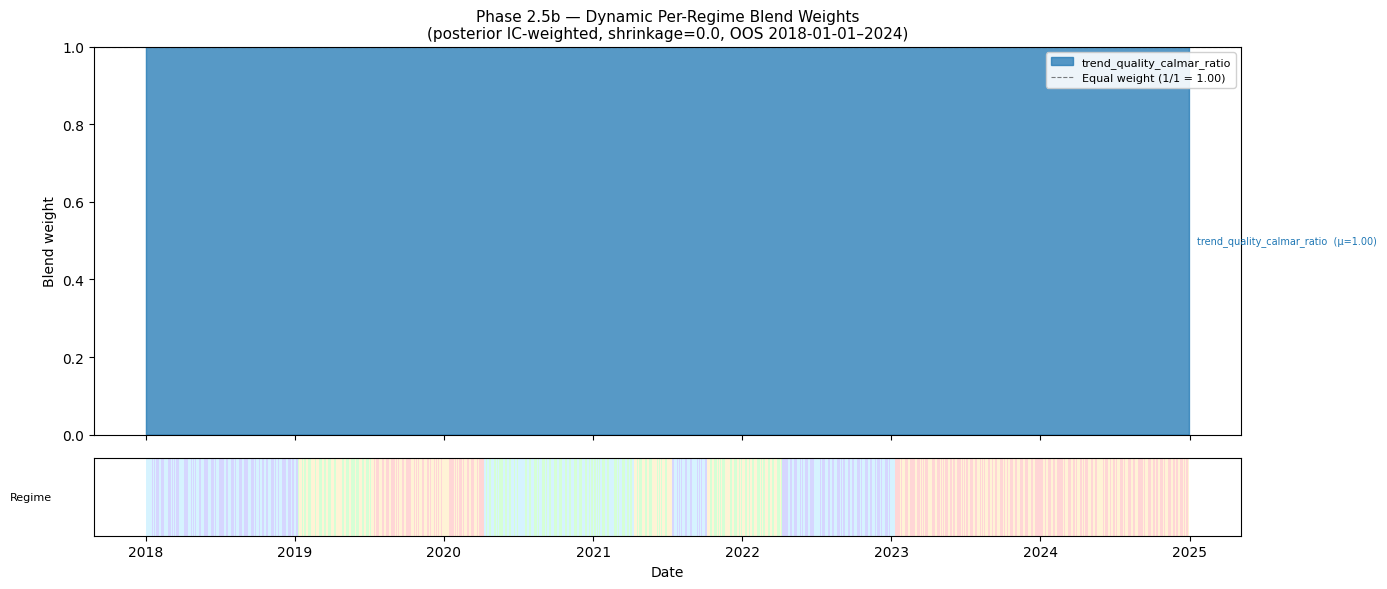

In [26]:
from qframe.viz.charts import plot_blend_weights

# Hard regime labels for the optional regime strip at the bottom
hard_labels = az.hard_labels(oos_start=OOS_START)

fig = plot_blend_weights(
    blend_weights=blend_weights_df,
    hard_labels=hard_labels,
    title=f'Phase 2.5b — Dynamic Per-Regime Blend Weights\n(posterior IC-weighted, shrinkage={SHRINKAGE}, OOS {OOS_START}–2024)',
)
plt.show()

### D2b — Comparison: Fixed IC Blend vs Dynamic Posterior Blend

The cell below builds a second combined equity curve using the **dynamic blend weights**
from above and compares it against the fixed IC-proportional blend from Section D.

What to look for:
- **Higher Sharpe** in dynamic blend → regime weighting adds value
- **Lower max drawdown** in dynamic blend → the model successfully de-risks during bad regimes
- **Similar or identical curves** → regime posteriors are near-uniform, so dynamic ≈ fixed;
  this is expected when only one factor is present (single-factor blends are trivially equal to weight=1.0)


Fixed IC-proportional blend  (Section D):
  Final NAV: $    59,257   CAGR=+29.0%   MaxDD=-10.3%   Sharpe≈3.05
Dynamic posterior blend       (Section D2):
  Final NAV: $    59,257   CAGR=+29.0%   MaxDD=-10.3%   Sharpe≈3.05

Note: with only 1 BHY factor the two blends are identical.
Divergence appears once 2+ BHY factors exist with different per-state ICs.


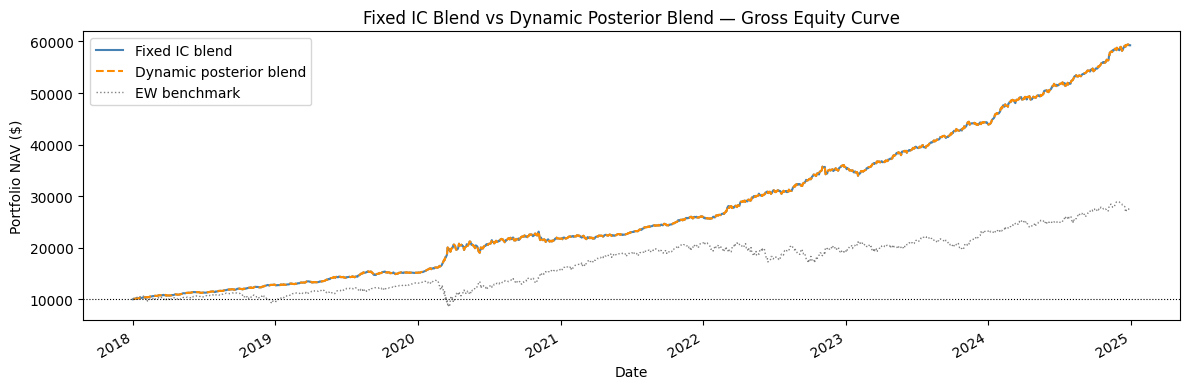

In [27]:
import warnings

def gross_equity_from_dynamic_blend(factor_dfs, blend_weights_df, oos_start=OOS_START,
                                    initial=INITIAL_INVESTMENT):
    """
    Build combined equity curve using time-varying blend weights.

    For each date t:
      combined_score[t, stock] = sum_i  blend_weights_df.loc[t, i] * factor_dfs[i].loc[t, stock]

    Then rank-weight the combined score (dollar-neutral, unit gross).
    """
    factor_names = list(factor_dfs.keys())
    bw = blend_weights_df.reindex(columns=factor_names)

    ref_df    = next(iter(factor_dfs.values()))
    all_dates = ref_df.index.intersection(bw.index)
    all_dates = all_dates[all_dates >= pd.Timestamp(oos_start)]

    combined = pd.DataFrame(0.0, index=all_dates, columns=ref_df.columns)
    for name, fdf in factor_dfs.items():
        w_series    = bw.loc[all_dates, name]
        fdf_aligned = fdf.reindex(index=all_dates)
        combined   += fdf_aligned.mul(w_series, axis=0)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        rank_w = WalkForwardValidator._rank_weights(combined)

    r = returns_df.reindex(index=all_dates)
    shared    = rank_w.columns.intersection(r.columns)
    daily_ret = (rank_w[shared] * r[shared]).sum(axis=1).fillna(0)
    return initial * (1 + daily_ret).cumprod()

# ── Fixed blend equity curve (recomputed from combined_factor — same as Section F) ───
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    _fixed_w = WalkForwardValidator._rank_weights(combined_factor)
_fixed_r = returns_df.loc[OOS_START:]
_shared   = _fixed_w.loc[OOS_START:].columns.intersection(_fixed_r.columns)
_fixed_daily = (_fixed_w.loc[OOS_START:][_shared] * _fixed_r[_shared]).sum(axis=1).fillna(0)
eq_fixed  = INITIAL_INVESTMENT * (1 + _fixed_daily).cumprod()

# ── Dynamic blend equity curve ────────────────────────────────────────────────
eq_dynamic = gross_equity_from_dynamic_blend(bhy_factor_dfs, blend_weights_df)

# ── Metrics comparison ────────────────────────────────────────────────────────
def equity_stats(eq, label):
    cagr    = (eq.iloc[-1] / INITIAL_INVESTMENT) ** (252 / len(eq)) - 1
    peak    = eq.cummax()
    max_dd  = ((eq - peak) / peak).min()
    daily_r = eq.pct_change().dropna()
    sharpe  = daily_r.mean() / daily_r.std() * np.sqrt(252)
    print(f'{label}:')
    print(f'  Final NAV: ${eq.iloc[-1]:>10,.0f}   CAGR={cagr:+.1%}   MaxDD={max_dd:.1%}   Sharpe≈{sharpe:.2f}')

equity_stats(eq_fixed,   'Fixed IC-proportional blend  (Section D)')
equity_stats(eq_dynamic, 'Dynamic posterior blend       (Section D2)')
print()
print('Note: with only 1 BHY factor the two blends are identical.')
print('Divergence appears once 2+ BHY factors exist with different per-state ICs.')

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
eq_fixed.rename('Fixed IC blend').plot(ax=ax, linewidth=1.5, color='steelblue')
eq_dynamic.rename('Dynamic posterior blend').plot(ax=ax, linewidth=1.5, color='darkorange', linestyle='--')
bm.reindex(eq_dynamic.index).rename('EW benchmark').plot(
    ax=ax, linewidth=1, linestyle=':', color='grey')
ax.axhline(INITIAL_INVESTMENT, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Fixed IC Blend vs Dynamic Posterior Blend — Gross Equity Curve')
ax.set_ylabel('Portfolio NAV ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section E — Net-of-Cost Backtest

This section runs the combined strategy through `WalkForwardValidator` to get
**net-of-cost** metrics — the same metrics used in Phase 1 gate evaluation.

### Cost model (DEFAULT_COST_PARAMS)

| Component | Value |
|-----------|-------|
| Bid-ask spread | 10 bps (5 bps each side) |
| Market impact (Almgren-Chriss) | γ=30, η=0.6, adv_fraction=10% |
| Short borrow cost | 50 bps/year |
| Funding cost | 0 bps/year |

These are conservative estimates for a mid/large-cap S&P 500 universe.  A live
implementation would see lower spreads for liquid names and higher borrow costs
for popular shorts.

### Walk-forward validation

The `WalkForwardValidator` applies the standard Phase 1 OOS protocol:
- OOS start: 2018-01-01
- Horizon: 1 day (daily rebalancing)
- ICIR window: 63 days

The combined factor function wraps the blend computed in Section D.


In [28]:
# Capture combined_factor in closure for the validator
_combined_factor_cache = combined_factor.copy()

def combined_factor_fn(prices_arg: pd.DataFrame) -> pd.DataFrame:
    """Return pre-computed combined factor (IC-blended, regime-scaled)."""
    return _combined_factor_cache.reindex(
        index=prices_arg.index, columns=prices_arg.columns
    )

validator = WalkForwardValidator(
    factor_fn   = combined_factor_fn,
    oos_start   = OOS_START,
    horizon     = 1,
    cost_params = DEFAULT_COST_PARAMS,
)

print('Running walk-forward net-of-cost backtest...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    wf_result = validator.run(prices)
print('Done.')

to_annual = wf_result.turnover.mean() * 252        # fraction → full-book-turns/yr
print(f'\nNet-of-cost metrics (OOS {wf_result.oos_start} → {wf_result.oos_end}):')
print(f'  Mean IC:        {wf_result.ic_series.mean():.4f}')
print(f'  Mean net IC:    {wf_result.net_ic_series.mean():.4f}')
print(f'  ICIR:           {wf_result.icir_series.mean():.3f}')
print(f'  Mean turnover:  {wf_result.turnover.mean():.4f}/day  ({to_annual:.0%}/yr one-way)')

Running walk-forward net-of-cost backtest...
Done.

Net-of-cost metrics (OOS 2018-01-01 → 2024-12-30):
  Mean IC:        0.0587
  Mean net IC:    0.0586
  ICIR:           0.306
  Mean turnover:  0.0350/day  (883%/yr one-way)


---
## Section F — Chart 20: Combined Equity Curve + Drawdown

This chart shows the combined strategy's gross NAV trajectory alongside:
- The equal-weight S&P 500 benchmark (grey dashed)
- Each individual BHY-significant factor's unconditional curve (for comparison)

The bottom panel shows the drawdown from peak — the most intuitive risk metric for a
portfolio investor.  A long/short strategy should have drawdowns that are independent
of market direction (a large S&P 500 rally should not cause the long/short book to draw down).


Combined strategy: NAV=$59,257  MaxDD=-10.3%  (should match Section B for single-factor)


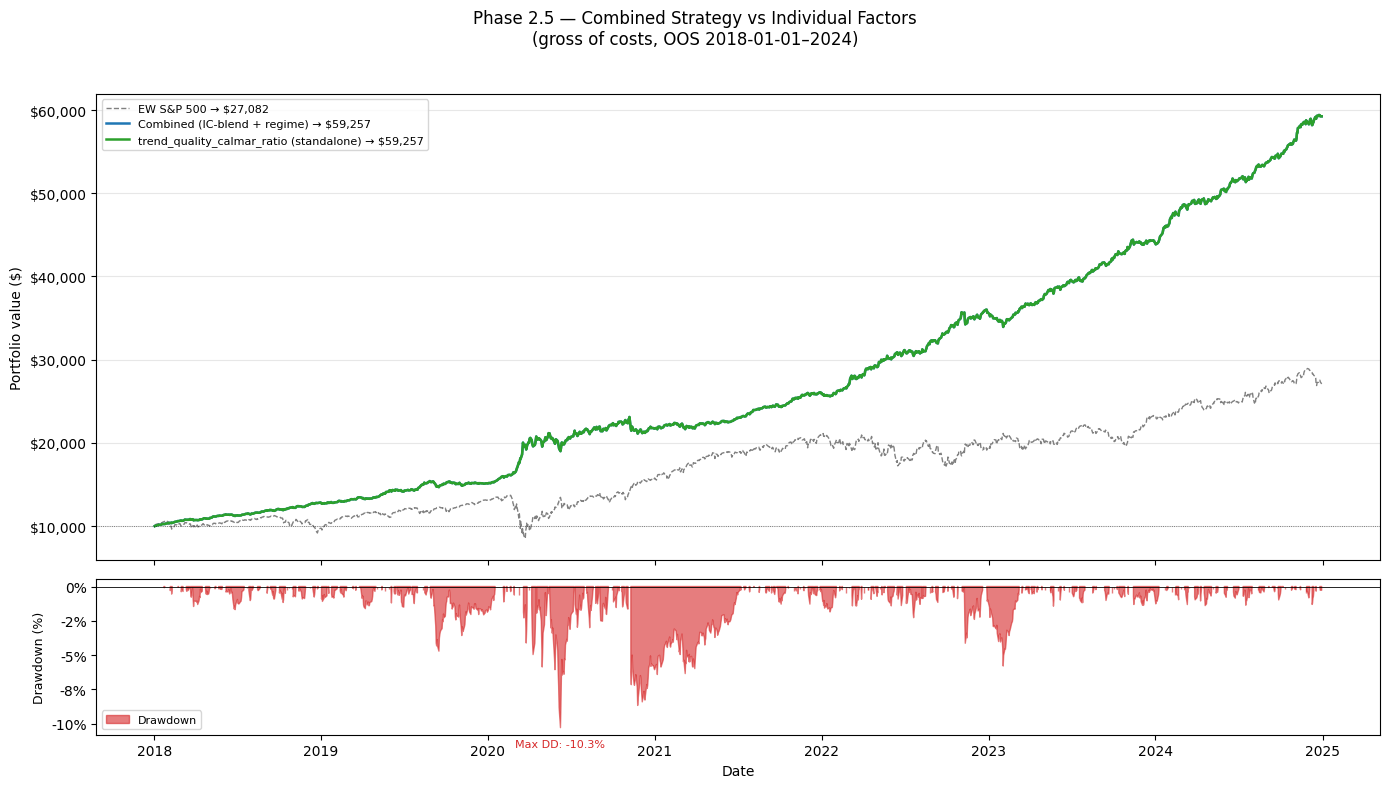

In [29]:
import warnings

def _build_gross_equity(factor_df, oos_start=OOS_START, initial=INITIAL_INVESTMENT):
    """Dollar-neutral gross equity curve — same helper pattern as Section B."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        w = WalkForwardValidator._rank_weights(factor_df)
    w   = w.loc[oos_start:]
    r   = returns_df.loc[oos_start:]
    shared    = w.columns.intersection(r.columns)
    daily_ret = (w[shared] * r[shared]).sum(axis=1)
    return initial * (1 + daily_ret.fillna(0)).cumprod()

# Combined strategy gross equity curve
combined_eq = _build_gross_equity(combined_factor)

# Sanity check — NAV and MaxDD should match Section B for single-factor case
_peak = combined_eq.cummax()
_dd   = ((combined_eq - _peak) / _peak).min()
print(f'Combined strategy: NAV=${combined_eq.iloc[-1]:,.0f}  MaxDD={_dd:.1%}  '
      f'(should match Section B for single-factor)')

all_curves = {'Combined (IC-blend + regime)': combined_eq}
for name, b in baselines.items():
    all_curves[f'{name} (standalone)'] = b['eq']

fig = plot_combined_equity(
    equity_curves=all_curves,
    benchmark=bm.reindex(combined_eq.index),
    initial_investment=INITIAL_INVESTMENT,
    title=f'Phase 2.5 — Combined Strategy vs Individual Factors\n(gross of costs, OOS {OOS_START}–2024)',
)
plt.show()

---
## Section G — Chart 21: Rolling 12-Month Sharpe Ratio

This chart diagnoses **stability**: is the combined strategy's Sharpe ratio consistent
across years, or is it driven by one exceptional year?

**What to look for:**
- Rolling Sharpe consistently above the Gate 3 threshold (0.5): strategy is reliable
- Rolling Sharpe crashing in 2020 (COVID) or 2022 (rate shock): regime sensitivity
- Rolling Sharpe recovering after a drawdown: signal is resilient, not permanently broken
- Long stretches below threshold: the strategy may have a structural drawdown period

The Gate 3 Sharpe threshold (0.5) appears as a red dashed line.  Green shading above it
and red shading below it make it easy to see what fraction of time the strategy was "on"
vs "off" from a risk-adjusted perspective.


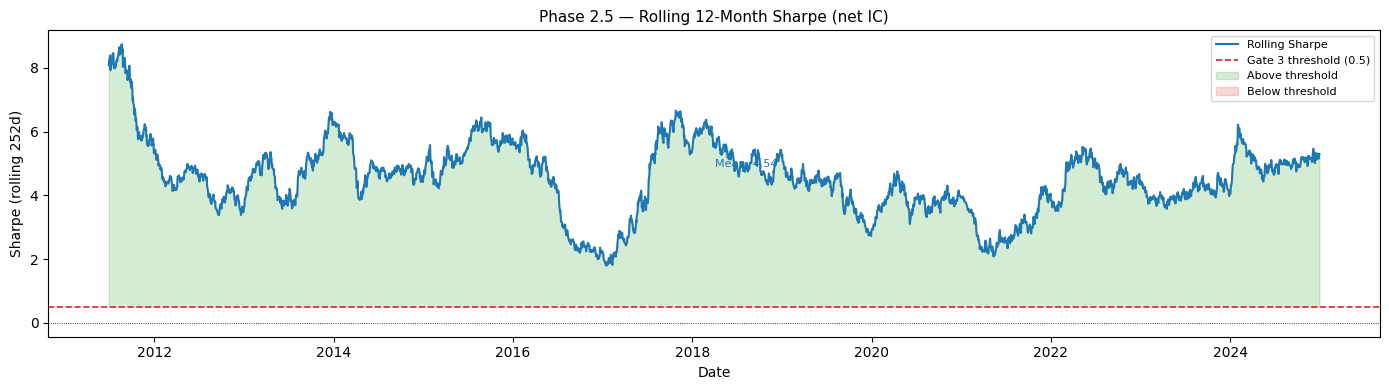

In [30]:
fig = plot_rolling_sharpe(
    ic_series=wf_result.net_ic_series,
    window=252,
    title='Phase 2.5 — Rolling 12-Month Sharpe (net IC)',
    threshold=0.5,
)
plt.show()


---
## Section H — Gate 3 Verdict

Gate 3 is the final quantitative hurdle before Phase 3 (live deployment planning).

### The 4 Gate 3 criteria

| Criterion | Threshold | Why this matters |
|-----------|-----------|-----------------|
| Net-of-cost Sharpe | ≥ 0.5 | Minimum institutional quality threshold for a long/short book |
| Maximum drawdown | < 25% | Acceptable peak-to-trough loss for a levered strategy |
| Worst calendar year | > −15% | Limits catastrophic tail risk that would force deleveraging |
| Cost efficiency (net IC / gross IC) | ≥ 0.90 | Transaction costs must not consume more than 10% of alpha |

### Why cost efficiency, not raw turnover?

A raw turnover cap (e.g. < 200%/yr) is a blunt instrument: it flags high-turnover
*high-reward* strategies as failures while doing nothing about low-turnover *low-IC*
strategies that are equally uninvestable.

**Cost efficiency** asks the right question directly: *how much of the gross signal
survives after realistic transaction costs?*  A strategy with 883%/yr turnover but
net IC = gross IC (costs ≈ zero) is fine.  A strategy with only 50%/yr turnover that
loses 30% of its IC to costs is not.

**Operational note** (soft warning, not a gate criterion): if annual turnover exceeds
500%, flag for execution review at scale — market impact will be meaningful beyond
~$50M AUM.  This does not block Gate 3.

### Interpreting a FAIL

- **Sharpe < 0.5:** Signal is too weak or inconsistent to be worth implementing live.
  Gather more BHY-significant factors.
- **Max DD ≥ 25%:** Concentration risk — add uncorrelated factors or reduce gross exposure.
- **Worst year ≤ −15%:** Catastrophic tail risk — apply tighter regime gating.
- **Cost efficiency < 90%:** Transaction costs are eating the alpha.  Options: reduce
  rebalancing frequency (check IC decay half-life first — this costs alpha proportional to
  the half-life), widen holding period, or add a turnover damper (α-blend of fresh/prior
  weights).

In [ ]:
import numpy as np
import warnings

# ── Gate 3 metrics ───────────────────────────────────────────────────────────
net_ic  = wf_result.net_ic_series.dropna()
gross_ic = wf_result.ic_series.dropna()

sharpe  = float(net_ic.mean() / net_ic.std() * np.sqrt(252))
peak    = combined_eq.cummax()
max_dd  = float((combined_eq - peak).div(peak).min())

# Annual returns
try:
    annual_eq = combined_eq.resample('YE').last()
except ValueError:
    annual_eq = combined_eq.resample('A').last()
annual_ret = annual_eq.pct_change().dropna()
worst_year = float(annual_ret.min()) if len(annual_ret) > 0 else 0.0

# Cost efficiency: fraction of gross IC surviving after costs
# Values near 1.0 = costs negligible.  < 0.90 = costs eating >10% of alpha.
mean_gross = float(gross_ic.mean())
mean_net   = float(net_ic.mean())
cost_efficiency = mean_net / mean_gross if mean_gross > 0 else 1.0

# Operational note (soft warning only, not a gate criterion)
turnover_annual = float(wf_result.turnover.mean() * 252)

# ── Print verdict ─────────────────────────────────────────────────────────────
def verdict(val, threshold, op='ge'):
    passed = val >= threshold if op == 'ge' else val < threshold
    return '✅ PASS' if passed else '❌ FAIL'

print('=' * 68)
print('GATE 3 VERDICT — Phase 2.5 Combined Strategy')
print('=' * 68)
print(f'Net Sharpe (annual):          {sharpe:>7.3f}    {verdict(sharpe, 0.5)}    (threshold ≥ 0.5)')
print(f'Max drawdown (gross):         {max_dd:>7.1%}    {verdict(-max_dd, -0.25)}   (threshold < 25%)')
print(f'Worst calendar year:          {worst_year:>7.1%}    {verdict(worst_year, -0.15)}   (threshold > −15%)')
print(f'Cost efficiency (net/gross):  {cost_efficiency:>7.1%}    {verdict(cost_efficiency, 0.90)}   (threshold ≥ 90%)')
print('-' * 68)
print(f'[Note] Annual turnover:       {turnover_annual:>7.0%}    {"⚠️  review at scale >$50M AUM" if turnover_annual > 5.0 else "ok"}  (soft limit >500%)')
print('=' * 68)

all_pass = (
    sharpe >= 0.5 and
    max_dd > -0.25 and
    worst_year > -0.15 and
    cost_efficiency >= 0.90
)

if all_pass:
    print('\n🟢 GATE 3 PASSED — Proceed to Phase 3 (live deployment planning)')
    print('   Next step: regime-conditional position sizing, borrow feasibility check,')
    print('   prime broker execution cost audit.')
else:
    print('\n🔴 GATE 3 FAILED — Document result in KB, identify failing criteria.')
    if sharpe < 0.5:
        print('   → Sharpe too low: gather more BHY-significant factors via Phase 1.')
    if max_dd <= -0.25:
        print('   → Max DD too large: add uncorrelated factors or reduce gross exposure.')
    if worst_year <= -0.15:
        print('   → Worst year too bad: apply tighter regime gating or reduce leverage.')
    if cost_efficiency < 0.90:
        print(f'   → Cost efficiency {cost_efficiency:.1%}: costs consuming >{1-cost_efficiency:.0%} of alpha.')
        print('     Check IC decay half-life; consider widening holding period or turnover damping.')
print('=' * 68)

In [32]:
# Log the combined strategy as an ensemble result in the KB
import json

ensemble_metrics = {
    'ic':          float(net_ic.mean()),
    'icir':        float(net_ic.mean() / net_ic.std()),
    'net_ic':      float(net_ic.mean()),
    'sharpe':      sharpe,
    'max_drawdown': max_dd,
    'turnover':    float(wf_result.turnover.mean()),
    'oos_start':   OOS_START,
    'oos_end':     wf_result.oos_end,
    'gate_level':  3,
    'passed_gate': int(all_pass),
    'notes':       json.dumps({
        'type':        'ensemble_phase25',
        'n_factors':   len(bhy_factor_dfs),
        'factor_names': list(bhy_factor_dfs.keys()),
        'blend_weights': ic_weights_norm,
        'worst_year':  worst_year,
        'annual_turnover': turnover_annual,
    }),
}

# Register as a synthetic ensemble hypothesis
hyp_id = kb.add_hypothesis(
    factor_name   = 'phase25_combined',
    description   = (f'Phase 2.5 IC-blend of {len(bhy_factor_dfs)} BHY-significant factors '
                     f'with regime gating (lift≥{LIFT_THRESHOLD}×)'),
    rationale     = 'Combines independent alpha sources; regime gating reduces drawdowns',
    mechanism_score = 5,
    status        = 'passed' if all_pass else 'failed',
)
impl_id = kb.add_implementation(
    hypothesis_id = hyp_id,
    code          = 'IC-proportional blend — see phase25_portfolio.ipynb',
    notes         = f'factor_type=ensemble_phase25 factors={list(bhy_factor_dfs.keys())}',
)
result_id = kb.log_result(impl_id, ensemble_metrics)

print(f'Logged to KB: hyp_id={hyp_id}, impl_id={impl_id}, result_id={result_id}')
print(f'Status: {"PASSED" if all_pass else "FAILED"}')


Logged to KB: hyp_id=106, impl_id=104, result_id=112
Status: FAILED
